In [ ]:
# ==========================================
# CELL 1: IMPORTS & GLOBAL CONFIGURATION
# ==========================================
import random
import os
from collections import Counter
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

def set_seed(seed: int = 42) -> None:
    """Pins all random number generators to ensure 100% reproducibility."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Enforce determinism globally
set_seed(42)

# Hardware acceleration setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Random seed anchored to 42 for fully deterministic training.")
print(f"Hardware accelerator in use: {device}")

Device in use for training: cuda


In [20]:
# ==========================================
# CELL 2: DATA PROCESSING & DATALOADERS
# ==========================================

def load_and_split_data(csv_path):
    """
    Loads dataset and splits it into Train (80%), Validation (10%) and Test (10%)
    maintaining class stratification.
    """
    df = pd.read_csv(csv_path)
    df['tweet_text'] = df['tweet_text'].astype(str)
    
    X = df['tweet_text'].values
    y = df['tweet_sentiment_value'].values
    
    # First split: separate Test (10%) and the rest (90%)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.10, stratify=y, random_state=42
    )
    
    # Second split: from the remaining 90%, extract 80% for Train and 10% for Val
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=(1/9), stratify=y_temp, random_state=42
    )
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def build_vocab(texts, min_freq=2):
    """
    Builds the vocabulary based EXCLUSIVELY on the Train Set.
    Adds the special tokens <PAD> (0) and <UNK> (1).
    """
    counter = Counter()
    for text in texts:
        tokens = text.strip().split()
        counter.update(tokens)
        
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    
    # Add only words that appear at least min_freq times to the vocab
    for word, freq in counter.items():
        if freq >= min_freq:
            word2idx[word] = idx
            idx += 1
            
    return word2idx


class TweetDataset(Dataset):
    """
    Custom PyTorch Dataset for tokenization and sequence padding.
    """
    def __init__(self, texts, labels, word2idx, max_len=32):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
        
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        tokens = text.strip().split()
        
        # Mapping Token -> ID 
        token_ids = [self.word2idx.get(word, 1) for word in tokens]
        
        # Truncating: if the sequence is longer than MAX_LEN, we cut it off.
        if len(token_ids) > self.max_len:
            token_ids = token_ids[:self.max_len]
            
        # Padding: if it's shorter, we add <PAD> (0) until we reach MAX_LEN
        else:
            pad_len = self.max_len - len(token_ids)
            token_ids = token_ids + [0] * pad_len
            
        # Return the tensors. The tokens in int64 (long), the labels in int64.
        # type lang (int64) is mandatory for PyTorch's nn.Embedding
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


def get_dataloaders(csv_path, batch_size=64, max_len=32):
    """
    Orchestrates the split, vocabulary creation, and returns the DataLoaders.
    Also returns the word2idx and training labels for computing class weights later.
    """
    # 1. Get the data splits
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_and_split_data(csv_path)
    
    # 2. Build Vocabulary only on Train
    word2idx = build_vocab(X_train, min_freq=2)
    print(f"Vocabulary Size (with min_freq=2): {len(word2idx)}")
    
    # 3. Instantiate the Datasets
    train_dataset = TweetDataset(X_train, y_train, word2idx, max_len)
    val_dataset = TweetDataset(X_val, y_val, word2idx, max_len)
    test_dataset = TweetDataset(X_test, y_test, word2idx, max_len)
    
    # 4. Create the DataLoaders
    # Hardware optimizations: pin_memory=True speeds up the transfer to GPU if present.
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    
    return train_loader, val_loader, test_loader, word2idx, y_train
 

In [21]:
# ==========================================
# CELL 3: MODEL ARCHITECTURE
# ==========================================
class TweetBiLSTM(nn.Module):
    """
    Bidirectional LSTM architecture for short text sentiment classification.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout_rate, pad_idx=0):
        super(TweetBiLSTM, self).__init__()
        
        # 1. Embedding Layer: Learne the vector representations from scratch
        # The padding_idx=0 ensures that the <PAD> token does not influence the gradients
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, 
            embedding_dim=embedding_dim, 
            padding_idx=pad_idx
        )
        
        # 2. Dropout for regularization 
        self.dropout = nn.Dropout(dropout_rate)
        
        # 3. Recurrent Layer: Single BiLSTM
        # batch_first=True -> the tensors will have shape [batch_size, seq_len, features]
        self.lstm = nn.LSTM(
            input_size=embedding_dim, 
            hidden_size=hidden_dim, 
            num_layers=1, 
            bidirectional=True, 
            batch_first=True
        )
        
        # 4. Linear/Output Layer
        # The input is hidden_dim * 2 because we concatenate the forward and backward directions
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text):
        # text: [batch_size, seq_len]
        
        # Passing through the Embedding layer
        # embedded: [batch_size, seq_len, embedding_dim]
        embedded = self.dropout(self.embedding(text))
        
        # Passing through the BiLSTM
        # hidden contains the last hidden state for each direction
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Extract the last hidden states (forward and backward)
        # Index -2: last forward cell, Index -1: last backward cell
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        
        # Concatenate the forward and backward hidden states
        # hidden_cat: [batch_size, hidden_dim * 2]
        hidden_cat = self.dropout(torch.cat((hidden_forward, hidden_backward), dim=1))
        
        # Output logits (Softmax is handled internally by nn.CrossEntropyLoss)
        output = self.fc(hidden_cat)
        
        return output

In [22]:

# ==========================================
# CELL 4: LOSS, METRICS, AND TRAINING PIPELINE
# ==========================================

def get_criterion_and_weights(train_labels, device):
    """
    Calculate the weights for each class based on their frequency in the training set
    and return the loss function configured with these weights.
    """
    # Ensure that the labels are a numpy array for scikit-learn
    labels_array = np.array(train_labels)
    
    # compute_class_weight with 'balanced' calculates the weights inversely
    # proportional to the frequencies of the classes in the input data.
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels_array),
        y=labels_array
    )
    
    # Convert the numpy array in a PyTorch tensor (must be float32) and move it to GPU
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    
    # Initialize the loss function by passing the weights.
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    
    return criterion, weights_tensor

def compute_macro_f1(true_labels, predictions):
    """
    Function to compute the Macro F1-Score at the end of each epoch.
    Takes as input lists or numpy arrays of true labels and predictions.
    """
    # average='macro' calculates the F1 for each class independently and then takes the arithmetic mean.
    # Treats all classes with the same importance.
    return f1_score(true_labels, predictions, average='macro')

class EarlyStopping:
    """
    Monitors validation metrics to stop training when performance degrades (overfitting).
    """
    def __init__(self, patience=3, path='best_tweet_bilstm.pth'):
        self.patience = patience # number of epochs to wait for improvement before stopping
        self.path = path #where to save the best model weights
        self.counter = 0
        self.best_macro_f1 = None
        self.early_stop = False

    def __call__(self, val_macro_f1, model):
        # First call: always save the model
        if self.best_macro_f1 is None:
            self.best_macro_f1 = val_macro_f1
            self.save_checkpoint(model)
            
        elif val_macro_f1 <= self.best_macro_f1:
            self.counter += 1
            print(f"    [EarlyStopping] No improvement. Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                
        else:
            print(f"    [EarlyStopping] F1-Score improved ({self.best_macro_f1:.4f} --> {val_macro_f1:.4f}). Saving weights...")
            self.best_macro_f1 = val_macro_f1
            self.save_checkpoint(model)
            self.counter = 0 

    def save_checkpoint(self, model):
        # save only the state_dict (weights) of the model, which is more efficient
        torch.save(model.state_dict(), self.path)

def train_epoch(model, dataloader, optimizer, criterion, device):
    """
    Executes a single training epoch over the dataset.
    """
    model.train() # Set the model in training mode (activates Dropout)
    total_loss = 0
    all_preds = []
    all_labels = []

    for texts, labels in dataloader:
        texts, labels = texts.to(device), labels.to(device)

        # 1. Equal gradients to zero from the previous step to prevent accumulation
        optimizer.zero_grad()
        
        # 2. Forward pass (calculate the predictions)
        predictions = model(texts)
        
        # 3. Calculate the loss (error)
        loss = criterion(predictions, labels)
        
        # 4. Backward pass (calculate the gradients)
        loss.backward()
        
        # 5. Update the weights (Mini-Batch Stochastic Gradient Descent)
        optimizer.step()

        # Collect statistics
        total_loss += loss.item()
        
        # Estraiamo la classe con il punteggio più alto (argmax)
        preds = torch.argmax(predictions, dim=1)
        
        # Salviamo predizioni ed etichette per calcolare l'F1-Score a fine epoca
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Calculate averages and metrics for the ENTIRE epoch
    avg_loss = total_loss / len(dataloader)
    macro_f1 = compute_macro_f1(all_labels, all_preds) 
    
    return avg_loss, macro_f1

def evaluate_epoch(model, dataloader, criterion, device):
    """
    Executes a single evaluation epoch (Validation or Test).
    """
    model.eval() # Deactivates Dropout for stable predictions
    total_loss = 0
    all_preds = []
    all_labels = []

    # Deactivating gradient calculations for evaluation to save memory and computation
    with torch.no_grad():
        for texts, labels in dataloader:
            texts, labels = texts.to(device), labels.to(device)

            # Solo forward pass
            predictions = model(texts)
            loss = criterion(predictions, labels)

            total_loss += loss.item()
            preds = torch.argmax(predictions, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    macro_f1 = compute_macro_f1(all_labels, all_preds)
    
    return avg_loss, macro_f1

Initializing Grid Search pipeline...
Vocabulary Size (with min_freq=2): 7095

 STARTING HYPERPARAMETER GRID SEARCH 

---> Training: Config 1 (Baseline)
  Epoch 01/15 | Train Loss: 1.0499 - F1: 0.3947 | Val Loss: 0.9217 - F1: 0.5372
  Epoch 02/15 | Train Loss: 0.9261 - F1: 0.5324 | Val Loss: 0.8300 - F1: 0.5806
    [EarlyStopping] F1-Score improved (0.5372 --> 0.5806). Saving weights...
  Epoch 03/15 | Train Loss: 0.8584 - F1: 0.5850 | Val Loss: 0.7746 - F1: 0.6053
    [EarlyStopping] F1-Score improved (0.5806 --> 0.6053). Saving weights...
  Epoch 04/15 | Train Loss: 0.7993 - F1: 0.6172 | Val Loss: 0.7452 - F1: 0.6272
    [EarlyStopping] F1-Score improved (0.6053 --> 0.6272). Saving weights...
  Epoch 05/15 | Train Loss: 0.7544 - F1: 0.6405 | Val Loss: 0.7309 - F1: 0.6293
    [EarlyStopping] F1-Score improved (0.6272 --> 0.6293). Saving weights...
  Epoch 06/15 | Train Loss: 0.7279 - F1: 0.6516 | Val Loss: 0.7069 - F1: 0.6490
    [EarlyStopping] F1-Score improved (0.6293 --> 0.6490). S

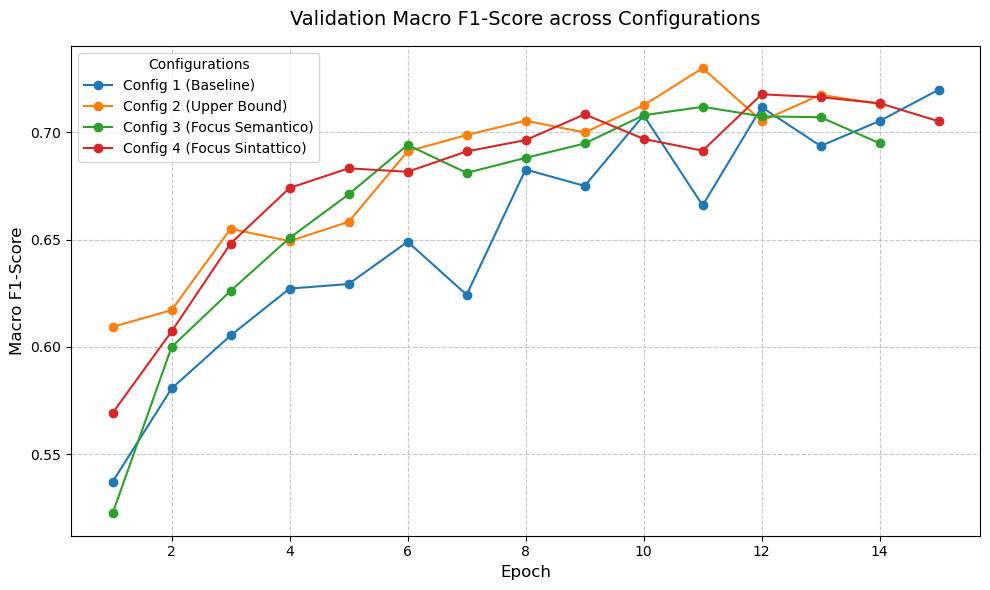


 TEST SET CLASSIFICATION REPORT 
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0: Negativo  |      0.8842 |   0.7985 |     0.8392 |  918      |
| 1: Neutro    |      0.5319 |   0.7258 |     0.6139 |  310      |
| 2: Positivo  |      0.717  |   0.6441 |     0.6786 |  236      |
| accuracy     |      0.7582 |   0.7582 |     0.7582 |    0.7582 |
| macro avg    |      0.711  |   0.7228 |     0.7105 | 1464      |
| weighted avg |      0.7826 |   0.7582 |     0.7656 | 1464      |


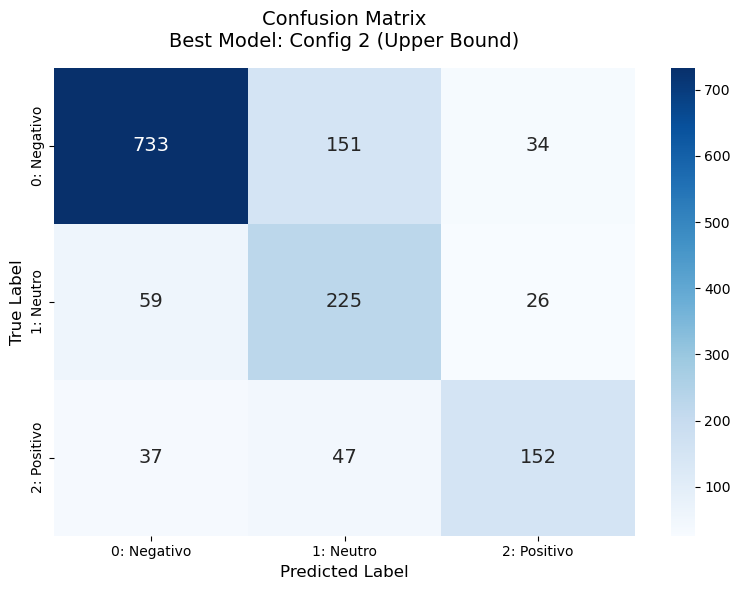

In [ ]:
# ==========================================
# 7. HYPERPARAMETER OPTIMIZATION & EVALUATION
# ==========================================

if __name__ == "__main__":
    print("Initializing Grid Search pipeline...")
    
    # Dataset and DataLoader instantiation
    CSV_PATH = 'kaggle_dataset_clean.csv'
    train_loader, val_loader, test_loader, word2idx, train_labels = get_dataloaders(CSV_PATH, batch_size=64, max_len=32)
    
    VOCAB_SIZE = len(word2idx)
    OUTPUT_DIM = 3
    MAX_EPOCHS = 15 

    criterion, weights = get_criterion_and_weights(train_labels, device)

    # Grid search parameter definitions
    configurations = {
        "Config 1 (Baseline)":         {"emb": 64,  "hid": 64,  "drop": 0.5, "lr": 1e-3},
        "Config 2 (Upper Bound)":      {"emb": 128, "hid": 128, "drop": 0.5, "lr": 1e-3},
        "Config 3 (Focus Semantico)":  {"emb": 128, "hid": 64,  "drop": 0.3, "lr": 5e-4},
        "Config 4 (Focus Sintattico)": {"emb": 64,  "hid": 128, "drop": 0.3, "lr": 1e-3}
    }

    # Create target directories for artifacts if they do not exist
    os.makedirs("images", exist_ok=True)

    best_overall_f1 = 0
    best_config_name = ""
    os.makedirs("checkpoints", exist_ok=True)
    best_model_path = "best_overall_model.pth"
    
    # Dictionary to track validation metrics for visualization
    training_history = {name: {'val_f1': []} for name in configurations.keys()}

    print(f"\n{'='*50}\n STARTING HYPERPARAMETER GRID SEARCH \n{'='*50}")

    for config_name, params in configurations.items():
        print(f"\n---> Training: {config_name}")
        
        # Model initialization and optimizer setup
        model = TweetBiLSTM(VOCAB_SIZE, params['emb'], params['hid'], OUTPUT_DIM, params['drop']).to(device)
        optimizer = optim.Adam(model.parameters(), lr=params['lr'])
        
        current_model_path = f"checkpoints/model_{config_name.replace(' ', '_')}.pth"
        early_stopping = EarlyStopping(patience=3, path=current_model_path)

        # Training loop
        for epoch in range(MAX_EPOCHS):
            train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_f1 = evaluate_epoch(model, val_loader, criterion, device)
            
            training_history[config_name]['val_f1'].append(val_f1)

            print(f"  Epoch {epoch+1:02d}/{MAX_EPOCHS} | Train Loss: {train_loss:.4f} - F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} - F1: {val_f1:.4f}")
            
            early_stopping(val_f1, model)
            if early_stopping.early_stop:
                print(" Early Stopping triggered.")
                break
        
        # Best model checkpointing
        if early_stopping.best_macro_f1 > best_overall_f1:
            best_overall_f1 = early_stopping.best_macro_f1
            best_config_name = config_name
            shutil.copyfile(current_model_path, best_model_path)

    print(f"\n{'='*50}\n BEST CONFIGURATION: {best_config_name} (Val F1: {best_overall_f1:.4f}) 🏆\n{'='*50}")

    # ==========================================
    # VISUALIZATION 1: LEARNING CURVES
    # ==========================================
    plt.figure(figsize=(10, 6))
    for config_name, history in training_history.items():
        plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], marker='o', label=config_name)
    
    plt.title('Validation Macro F1-Score across Configurations', fontsize=14, pad=15)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Macro F1-Score', fontsize=12)
    plt.legend(title='Configurations')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('images/validation_f1_comparison.png', dpi=300)
    plt.show()

    # ==========================================
    # FINAL EVALUATION ON UNSEEN TEST SET
    # ==========================================
    best_params = configurations[best_config_name]
    final_model = TweetBiLSTM(VOCAB_SIZE, best_params['emb'], best_params['hid'], OUTPUT_DIM, best_params['drop']).to(device)
    final_model.load_state_dict(torch.load(best_model_path))
    final_model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = final_model(texts)
            all_preds.extend(torch.argmax(predictions, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    class_names = ['0: Negativo', '1: Neutro', '2: Positivo']

    print("\n TEST SET CLASSIFICATION REPORT ")
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose().round(4)
    print(report_df.to_markdown())

    # ==========================================
    # VISUALIZATION 2: CONFUSION MATRIX
    # ==========================================
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    
    plt.title(f'Confusion Matrix\nBest Model: {best_config_name}', fontsize=14, pad=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('images/confusion_matrix_best_model.png', dpi=300)
    plt.show()